# Import

In [3]:
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    precision_recall_curve, recall_score
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import make_pipeline

import lightgbm as lgb


In [4]:
df = kagglehub.load_dataset(
KaggleDatasetAdapter.PANDAS,
"mkechinov/ecommerce-behavior-data-from-multi-category-store",
"2019-Oct.csv",
pandas_kwargs={
"nrows": 10_000_000,
"dtype": {
'event_type': 'category',
'product_id': 'int32',
'category_code': 'category',
'brand': 'category',
'price': 'float32',
'user_id': 'int32',
}
}
)

/var/folders/gx/_p6prf1d05bc3xk29_l_p4140000gn/T/ipykernel_13747/1155051505.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


# EDA/Cleaning

In [5]:
# Verify temporal range
print(df['event_time'].min(), df['event_time'].max())

2019-10-01 00:00:00 UTC 2019-10-08 17:26:09 UTC


In [6]:
df['event_type'].value_counts(normalize=True)

event_type
view        0.962782
cart        0.019935
purchase    0.017283
Name: proportion, dtype: float64

This specific retailer doesn't use remove_from_cart event. They are using override cart mechanics in API. So you can figured out removed from cart products as difference between purchase and cart events.

In [7]:
df['category_id'].nunique()

566

In [8]:
df['product_id'].nunique()

121903

In [9]:
df['category_code'].nunique()

123

In [10]:
#Clean the event time, remove UTC

df["event_time"] = pd.to_datetime(
    df["event_time"].str.replace(" UTC", "", regex=False),
    format="%Y-%m-%d %H:%M:%S",
)

In [11]:
# Stats descriptives (colonnes numériques)
df.describe()

,event_time,product_id,category_id,price,user_id
count,10000000,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07
mean,2019-10-04 23:35:08.081178368,1.011534e+07,2.056684e+18,2.960614e+02,5.317569e+08
min,2019-10-01 00:00:00,1.001588e+06,2.053014e+18,0.000000e+00,1.835035e+08
25%,2019-10-03 03:22:41,1.005115e+06,2.053014e+18,6.525000e+01,5.156193e+08
50%,2019-10-05 01:32:45,4.900087e+06,2.053014e+18,1.619100e+02,5.274672e+08
75%,2019-10-06 18:21:33,1.570007e+07,2.053014e+18,3.618200e+02,5.487683e+08
max,2019-10-08 17:26:09,5.560003e+07,2.175420e+18,2.574070e+03,5.581647e+08
std,NaN,1.124471e+07,1.681746e+16,3.669100e+02,1.715918e+07


In [12]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing': missing, '%': missing_pct}).query('missing > 0').sort_values('%', ascending=False)

,missing,%
category_code,3224119,32.2
brand,1388005,13.9
user_session,1,0.0


In [13]:
df['user_id'].nunique()

1070614

In [14]:
df_purchase = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())

/var/folders/gx/_p6prf1d05bc3xk29_l_p4140000gn/T/ipykernel_13747/985662042.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_purchase = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())


In [15]:
df_purchase.sort_values(ascending=False)

category_code
electronics.smartphone           79205
electronics.audio.headphone       7257
electronics.video.tv              4849
electronics.clocks                4495
computers.notebook                3914
                                 ...  
country_yard.furniture.bench         0
country_yard.furniture.hammok        0
apparel.dress                        0
apparel.jacket                       0
sport.tennis                         0
Name: event_type, Length: 123, dtype: int64

In [16]:
(df_purchase / df_purchase.sum() * 100).sort_values(ascending=False)

category_code
electronics.smartphone           59.461428
electronics.audio.headphone       5.448035
electronics.video.tv              3.640281
electronics.clocks                3.374523
computers.notebook                2.938350
                                   ...    
country_yard.furniture.bench      0.000000
country_yard.furniture.hammok     0.000000
apparel.dress                     0.000000
apparel.jacket                    0.000000
sport.tennis                      0.000000
Name: event_type, Length: 123, dtype: float64

In [17]:
# Lister les catégories à 0 achats
df_purchase[df_purchase == 0].index.tolist()
# Combien il y en a
(df_purchase == 0).sum()

np.int64(7)

In [18]:
# Catégories avec au moins 1 achat
df_purchase_clean = df_purchase[df_purchase > 0].sort_values(ascending=False)
df_purchase_clean

category_code
electronics.smartphone         79205
electronics.audio.headphone     7257
electronics.video.tv            4849
electronics.clocks              4495
computers.notebook              3914
                               ...  
apparel.scarf                      2
apparel.shoes.sandals              2
apparel.shorts                     2
apparel.shoes.ballet_shoes         1
apparel.skirt                      1
Name: event_type, Length: 116, dtype: int64

In [19]:
df["brand"] = df["brand"].astype(str).replace("nan", "unknown").astype("category")
df["has_brand"] = (df["brand"] != "unknown").astype("int8")

In [20]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing': missing, '%': missing_pct}).query('missing > 0').sort_values('%', ascending=False)

,missing,%
category_code,3224119,32.2
user_session,1,0.0


In [21]:
df = df.drop_duplicates()

In [22]:
n_bad_price = (df["price"] <= 0).sum()

In [23]:
n_bad_price

np.int64(15522)

In [24]:
df["has_valid_price"] = (df["price"] > 0).astype("int8")

# Preprocessing X, y

## Filtering X to keep only top 5 category_code

In [25]:
top5 = ['electronics.smartphone', 'electronics.audio.headphone', 'electronics.video.tv',
        'electronics.clocks', 'computers.notebook']

X = df[df['category_code'].isin(top5)]

In [26]:
X

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
3,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1
4,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1
9,2019-10-01 00:00:11,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb,1,1
11,2019-10-01 00:00:11,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101,1,1
16,2019-10-01 00:00:18,view,1801995,2053013554415534427,electronics.video.tv,haier,193.029999,537192226,e3151795-c355-4efa-acf6-e1fe1bebeee5,1,1
...,...,...,...,...,...,...,...,...,...,...,...
9999984,2019-10-08 17:26:08,view,1005105,2053013555631882655,electronics.smartphone,apple,1415.479980,512565865,4f98f4f3-60da-48aa-bc71-0d39b2eba526,1,1
9999985,2019-10-08 17:26:08,view,1307383,2053013558920217191,computers.notebook,asus,1282.140015,513451334,c2f51343-7977-4ac3-ae5a-5e274918310e,1,1
9999987,2019-10-08 17:26:08,view,1307293,2053013558920217191,computers.notebook,msi,866.710022,513956748,fdf662f6-e9a4-4991-9d2e-a8b5b6073441,1,1
9999989,2019-10-08 17:26:08,view,1004433,2053013555631882655,electronics.smartphone,samsung,257.149994,512963963,b61ab7c6-2a1a-4ef2-9e1d-1fa9b288fe9b,1,1


In [27]:
X = X.drop_duplicates()
# Il reste 35% des lignes, donc 1/3 des events sont compris sur ces 5 catégories

In [28]:
missing = X.isnull().sum()
missing_pct = (missing / len(X) * 100).round(1)
pd.DataFrame({'missing': missing, '%': missing_pct}).query('missing > 0').sort_values('%', ascending=False)

,missing,%
user_session,1,0.0


In [29]:
X = X.sort_values("event_time").reset_index(drop=True)

## Set Observation and prediction period for X

In [30]:

observation_end = pd.Timestamp("2019-10-06")
prediction_end  = pd.Timestamp("2019-10-09")

In [31]:
X_obs = X[X["event_time"] < observation_end].copy()
X_pred = X[X["event_time"] >= observation_end].copy()

In [32]:
X_obs

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
0,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1
1,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1
2,2019-10-01 00:00:11,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb,1,1
3,2019-10-01 00:00:11,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101,1,1
4,2019-10-01 00:00:18,view,1801995,2053013554415534427,electronics.video.tv,haier,193.029999,537192226,e3151795-c355-4efa-acf6-e1fe1bebeee5,1,1
...,...,...,...,...,...,...,...,...,...,...,...
2499772,2019-10-05 23:59:52,view,1004750,2053013555631882655,electronics.smartphone,samsung,197.789993,552859242,ac93027f-3447-4feb-afb3-83a79b74bc8f,1,1
2499773,2019-10-05 23:59:54,view,1004873,2053013555631882655,electronics.smartphone,samsung,380.309998,512536825,ff044704-7e4e-40ea-bebc-ec6690b6d5ce,1,1
2499774,2019-10-05 23:59:55,view,1005115,2053013555631882655,electronics.smartphone,apple,975.559998,550697012,41709209-2300-49d2-ae3e-c76be02a5731,1,1
2499775,2019-10-05 23:59:55,view,1306556,2053013558920217191,computers.notebook,lenovo,926.640015,513465266,8576dd95-91d5-47c3-aa50-6220118fbd38,1,1


In [33]:
X_pred

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price
2499777,2019-10-06 00:00:00,cart,1005116,2053013555631882655,electronics.smartphone,apple,1052.790039,557192362,3e516ca1-29d2-4ef0-96bb-d1fdaac62d08,1,1
2499778,2019-10-06 00:00:00,view,1005014,2053013555631882655,electronics.smartphone,samsung,603.619995,519093005,e0444ad7-cd5b-4501-8d09-b031a26ba67f,1,1
2499779,2019-10-06 00:00:01,cart,1004836,2053013555631882655,electronics.smartphone,samsung,230.589996,556720959,d1b1bd63-936c-49d4-b891-f7e08a416297,1,1
2499780,2019-10-06 00:00:02,view,1004249,2053013555631882655,electronics.smartphone,apple,730.260010,518895065,68a21481-6b44-4e72-8ea1-07ad6099a8d4,1,1
2499781,2019-10-06 00:00:04,view,1004249,2053013555631882655,electronics.smartphone,apple,730.260010,512640759,41621b6e-2a8a-4236-9f24-80e393cdefd7,1,1
...,...,...,...,...,...,...,...,...,...,...,...
3857586,2019-10-08 17:26:08,view,21409279,2053013561579406073,electronics.clocks,casio,45.820000,544509415,021a0c6e-570c-4bb0-a338-bbe58a197075,1,1
3857587,2019-10-08 17:26:08,view,1005105,2053013555631882655,electronics.smartphone,apple,1415.479980,512565865,4f98f4f3-60da-48aa-bc71-0d39b2eba526,1,1
3857588,2019-10-08 17:26:08,view,1307383,2053013558920217191,computers.notebook,asus,1282.140015,513451334,c2f51343-7977-4ac3-ae5a-5e274918310e,1,1
3857589,2019-10-08 17:26:08,view,1307293,2053013558920217191,computers.notebook,msi,866.710022,513956748,fdf662f6-e9a4-4991-9d2e-a8b5b6073441,1,1


## Create y with purchasers from prediction period

In [34]:
purchasers = set(X_pred.loc[X_pred["event_type"] == "purchase", "user_id"])


In [35]:
len(purchasers)

23267

In [36]:
y_purchasers = pd.DataFrame({"user_id": X_obs["user_id"].unique()})
y_purchasers["label"] = y_purchasers["user_id"].isin(purchasers).astype(int)

In [37]:
y_purchasers["label"].value_counts()
# Sur X_obs, env. 2 500 000 events sont enregistrés pour 375 000 utilisateurs unique, avec 9300 qui achèteront sur l'intervalle d'observation

label
0    365115
1      9386
Name: count, dtype: int64

In [38]:
y_purchasers

,user_id,label
0,550050854,0
1,535871217,0
2,537918940,0
3,530282093,0
4,537192226,0
...,...,...
374496,535049981,1
374497,543927802,0
374498,557194015,0
374499,552859242,0


# Feature engineering X_obs

## Global Features creation per user, for the observation period

In [39]:
X_obs["hour"] = X_obs["event_time"].dt.hour
X_obs["dayofweek"] = X_obs["event_time"].dt.dayofweek  # 0=Lundi
X_obs["is_weekend"] = (X_obs["dayofweek"] >= 5).astype("int8")


In [40]:
X_obs

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,has_brand,has_valid_price,hour,dayofweek,is_weekend
0,2019-10-01 00:00:01,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,1,1,0,1,0
1,2019-10-01 00:00:04,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,1,1,0,1,0
2,2019-10-01 00:00:11,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb,1,1,0,1,0
3,2019-10-01 00:00:11,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101,1,1,0,1,0
4,2019-10-01 00:00:18,view,1801995,2053013554415534427,electronics.video.tv,haier,193.029999,537192226,e3151795-c355-4efa-acf6-e1fe1bebeee5,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2499772,2019-10-05 23:59:52,view,1004750,2053013555631882655,electronics.smartphone,samsung,197.789993,552859242,ac93027f-3447-4feb-afb3-83a79b74bc8f,1,1,23,5,1
2499773,2019-10-05 23:59:54,view,1004873,2053013555631882655,electronics.smartphone,samsung,380.309998,512536825,ff044704-7e4e-40ea-bebc-ec6690b6d5ce,1,1,23,5,1
2499774,2019-10-05 23:59:55,view,1005115,2053013555631882655,electronics.smartphone,apple,975.559998,550697012,41709209-2300-49d2-ae3e-c76be02a5731,1,1,23,5,1
2499775,2019-10-05 23:59:55,view,1306556,2053013558920217191,computers.notebook,lenovo,926.640015,513465266,8576dd95-91d5-47c3-aa50-6220118fbd38,1,1,23,5,1


In [41]:
behavior = X_obs.groupby("user_id").agg(
    total_events   = ("event_type", "count"),
    total_views    = ("event_type", lambda x: (x == "view").sum()),
    total_carts    = ("event_type", lambda x: (x == "cart").sum()),
    total_purchases= ("event_type", lambda x: (x == "purchase").sum()),
    n_sessions     = ("user_session", "nunique"),
    n_days_active  = ("event_time", lambda x: x.dt.date.nunique()),
)

# Features de comportement dans l'intervalle d'observation choisi
# Prend beaucoup de temps les fonctions lambda, optimisable?

In [42]:
behavior

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active
user_id,,,,,,
241587569,1,1,0,0,1,1
241784978,1,1,0,0,1,1
244951053,5,5,0,0,2,2
258811396,3,3,0,0,1,1
263428680,1,1,0,0,1,1
...,...,...,...,...,...,...
557193252,1,1,0,0,1,1
557193392,2,2,0,0,1,1
557193489,1,1,0,0,1,1


In [43]:
behavior["has_ever_carted"] = (behavior["total_carts"] > 0).astype("int8")
behavior["has_ever_purchased"] = (behavior["total_purchases"] > 0).astype("int8")


In [44]:
behavior["has_ever_carted"].value_counts(normalize=True)

has_ever_carted
0    0.878283
1    0.121717
Name: proportion, dtype: float64

In [45]:
behavior["has_ever_purchased"].value_counts(normalize=True)

has_ever_purchased
0    0.895891
1    0.104109
Name: proportion, dtype: float64

In [46]:
behavior["view_to_cart_ratio"] = (
    behavior["total_carts"] / behavior["total_views"].replace(0, 1)
)
behavior["cart_to_purchase_ratio"] = (
    behavior["total_purchases"] / behavior["total_carts"].replace(0, 1)
)

#Est-ce que c'est des bonnes features? L'info est peut-être déjà présente

In [47]:
behavior

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio
user_id,,,,,,,,,,
241587569,1,1,0,0,1,1,0,0,0.0,0.0
241784978,1,1,0,0,1,1,0,0,0.0,0.0
244951053,5,5,0,0,2,2,0,0,0.0,0.0
258811396,3,3,0,0,1,1,0,0,0.0,0.0
263428680,1,1,0,0,1,1,0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
557193252,1,1,0,0,1,1,0,0,0.0,0.0
557193392,2,2,0,0,1,1,0,0,0.0,0.0
557193489,1,1,0,0,1,1,0,0,0.0,0.0


In [48]:
behavior["cart_to_purchase_ratio"].value_counts(ascending=False)

cart_to_purchase_ratio
0.000000     335512
1.000000      22964
0.500000       4504
2.000000       2795
0.333333       1843
              ...  
0.018868          1
15.000000         1
2.571429          1
0.352941          1
0.560000          1
Name: count, Length: 281, dtype: int64

## Session features creation

In [49]:
session_stats = X_obs.groupby(["user_id", "user_session"], as_index=False).agg(
    session_start = ("event_time", "min"),
    session_end   = ("event_time", "max"),
    session_events = ("event_time", "count"),
)

In [50]:
session_stats

,user_id,user_session,session_start,session_end,session_events
0,241587569,8a09b6c6-07e6-4f80-ae22-a6b400fc7894,2019-10-02 11:28:14,2019-10-02 11:28:14,1
1,241784978,db17076d-5be1-4f1e-acd1-a2baf23eb3fd,2019-10-04 08:00:07,2019-10-04 08:00:07,1
2,244951053,91769fdf-461b-4e43-9c73-88a07481b75c,2019-10-01 08:47:35,2019-10-01 08:48:28,2
3,244951053,ac5e27ca-6408-47ab-9837-19893a0334c2,2019-10-03 03:06:18,2019-10-03 03:08:27,3
4,258811396,5087bb70-6cd1-45d5-81e4-3ef6cbe9530a,2019-10-05 04:21:30,2019-10-05 04:25:35,3
...,...,...,...,...,...
634244,557193252,06b6403d-aea5-4829-9a6d-ecd125804204,2019-10-05 23:51:12,2019-10-05 23:51:12,1
634245,557193392,80192c3c-637c-495e-aef7-5ad848989340,2019-10-05 23:52:43,2019-10-05 23:53:20,2
634246,557193489,41988c90-65a9-412d-9b46-fb9965ee1b9f,2019-10-05 23:53:11,2019-10-05 23:53:11,1
634247,557193936,2c12f12d-93b8-4831-bcc5-bea36afc8f8a,2019-10-05 23:58:21,2019-10-05 23:58:43,2


In [51]:
session_stats["user_id"].nunique()
# Environ 2 sessions par user_id

374501

In [52]:
session_stats["session_duration"] = (
    session_stats["session_end"] - session_stats["session_start"]
)

In [53]:
session_stats

,user_id,user_session,session_start,session_end,session_events,session_duration
0,241587569,8a09b6c6-07e6-4f80-ae22-a6b400fc7894,2019-10-02 11:28:14,2019-10-02 11:28:14,1,0 days 00:00:00
1,241784978,db17076d-5be1-4f1e-acd1-a2baf23eb3fd,2019-10-04 08:00:07,2019-10-04 08:00:07,1,0 days 00:00:00
2,244951053,91769fdf-461b-4e43-9c73-88a07481b75c,2019-10-01 08:47:35,2019-10-01 08:48:28,2,0 days 00:00:53
3,244951053,ac5e27ca-6408-47ab-9837-19893a0334c2,2019-10-03 03:06:18,2019-10-03 03:08:27,3,0 days 00:02:09
4,258811396,5087bb70-6cd1-45d5-81e4-3ef6cbe9530a,2019-10-05 04:21:30,2019-10-05 04:25:35,3,0 days 00:04:05
...,...,...,...,...,...,...
634244,557193252,06b6403d-aea5-4829-9a6d-ecd125804204,2019-10-05 23:51:12,2019-10-05 23:51:12,1,0 days 00:00:00
634245,557193392,80192c3c-637c-495e-aef7-5ad848989340,2019-10-05 23:52:43,2019-10-05 23:53:20,2,0 days 00:00:37
634246,557193489,41988c90-65a9-412d-9b46-fb9965ee1b9f,2019-10-05 23:53:11,2019-10-05 23:53:11,1,0 days 00:00:00
634247,557193936,2c12f12d-93b8-4831-bcc5-bea36afc8f8a,2019-10-05 23:58:21,2019-10-05 23:58:43,2,0 days 00:00:22


## Session duration exploration (code not used yet, just to show outliers in session durations)

In [54]:
durations_sess = session_stats["session_duration"]

In [55]:
durations_sess.sort_values(ascending=False)

478207   4 days 15:51:15
499445   4 days 14:59:08
455424   4 days 14:24:53
485067   4 days 11:23:05
451626   4 days 09:48:16
               ...      
326409   0 days 00:00:00
326405   0 days 00:00:00
326397   0 days 00:00:00
326395   0 days 00:00:00
634248   0 days 00:00:00
Name: session_duration, Length: 634249, dtype: timedelta64[ns]

In [56]:
durations_sess.describe()

count                       634249
mean     0 days 00:11:24.219202552
std      0 days 02:16:41.016558241
min                0 days 00:00:00
25%                0 days 00:00:00
50%                0 days 00:00:52
75%                0 days 00:03:38
max                4 days 15:51:15
Name: session_duration, dtype: object

In [57]:
crazy_duration = durations_sess[durations_sess > "1 days"]

In [58]:
crazy_duration
# A supprimer des prochaines itérations du modèle après baseline?

26       1 days 18:32:26
94       1 days 00:00:15
155      2 days 00:57:39
181      1 days 01:03:37
232      2 days 05:58:00
               ...      
604016   1 days 04:14:10
604567   1 days 03:52:33
605614   1 days 00:50:35
607396   1 days 03:07:15
608618   1 days 02:25:02
Name: session_duration, Length: 1103, dtype: timedelta64[ns]

## Grouping Session features per user_id for the observation period

In [59]:
# INfos de session par user_ID sur l'intervalle d'observation

session_user = session_stats.groupby("user_id").agg(
    avg_session_duration    = ("session_duration", "mean"),
    median_session_duration = ("session_duration", "median"),
    max_session_duration    = ("session_duration", "max"),
    avg_events_per_session  = ("session_events", "mean"),
    max_events_per_session  = ("session_events", "max"),
)
session_user

,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
user_id,,,,,
241587569,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
241784978,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
244951053,0 days 00:01:31,0 days 00:01:31,0 days 00:02:09,2.5,3
258811396,0 days 00:04:05,0 days 00:04:05,0 days 00:04:05,3.0,3
263428680,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
...,...,...,...,...,...
557193252,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
557193392,0 days 00:00:37,0 days 00:00:37,0 days 00:00:37,2.0,2
557193489,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1


## Features grouping and final X, y

In [60]:
user_features = (behavior.join(session_user, how="left")
)

In [61]:
user_features

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
user_id,,,,,,,,,,,,,,,
241587569,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
241784978,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
244951053,5,5,0,0,2,2,0,0,0.0,0.0,0 days 00:01:31,0 days 00:01:31,0 days 00:02:09,2.5,3
258811396,3,3,0,0,1,1,0,0,0.0,0.0,0 days 00:04:05,0 days 00:04:05,0 days 00:04:05,3.0,3
263428680,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
557193252,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
557193392,2,2,0,0,1,1,0,0,0.0,0.0,0 days 00:00:37,0 days 00:00:37,0 days 00:00:37,2.0,2
557193489,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1


In [62]:
user_features.isna().sum()

total_events               0
total_views                0
total_carts                0
total_purchases            0
n_sessions                 0
n_days_active              0
has_ever_carted            0
has_ever_purchased         0
view_to_cart_ratio         0
cart_to_purchase_ratio     0
avg_session_duration       0
median_session_duration    0
max_session_duration       0
avg_events_per_session     0
max_events_per_session     0
dtype: int64

In [63]:
dataset = y_purchasers.merge(user_features, on="user_id", how="inner")

In [64]:
dataset

,user_id,label,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
0,550050854,0,7,7,0,0,1,1,0,0,0.0,0.0,0 days 00:03:16,0 days 00:03:16,0 days 00:03:16,7.0,7
1,535871217,0,10,10,0,0,2,1,0,0,0.0,0.0,0 days 00:01:40,0 days 00:01:40,0 days 00:02:41,5.0,7
2,537918940,0,4,4,0,0,1,1,0,0,0.0,0.0,0 days 00:01:36,0 days 00:01:36,0 days 00:01:36,4.0,4
3,530282093,0,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
4,537192226,0,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374496,535049981,1,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
374497,543927802,0,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
374498,557194015,0,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
374499,552859242,0,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1


In [65]:
X = dataset.drop(columns="label")

In [66]:
X

,user_id,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
0,550050854,7,7,0,0,1,1,0,0,0.0,0.0,0 days 00:03:16,0 days 00:03:16,0 days 00:03:16,7.0,7
1,535871217,10,10,0,0,2,1,0,0,0.0,0.0,0 days 00:01:40,0 days 00:01:40,0 days 00:02:41,5.0,7
2,537918940,4,4,0,0,1,1,0,0,0.0,0.0,0 days 00:01:36,0 days 00:01:36,0 days 00:01:36,4.0,4
3,530282093,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
4,537192226,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374496,535049981,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
374497,543927802,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
374498,557194015,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1
374499,552859242,1,1,0,0,1,1,0,0,0.0,0.0,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00,1.0,1


In [67]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374501 entries, 0 to 374500
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype          
---  ------                   --------------   -----          
 0   user_id                  374501 non-null  int32          
 1   total_events             374501 non-null  int64          
 2   total_views              374501 non-null  int64          
 3   total_carts              374501 non-null  int64          
 4   total_purchases          374501 non-null  int64          
 5   n_sessions               374501 non-null  int64          
 6   n_days_active            374501 non-null  int64          
 7   has_ever_carted          374501 non-null  int8           
 8   has_ever_purchased       374501 non-null  int8           
 9   view_to_cart_ratio       374501 non-null  float64        
 10  cart_to_purchase_ratio   374501 non-null  float64        
 11  avg_session_duration     374501 non-null  timedelta64[ns]
 12  me

In [68]:
for col in ["avg_session_duration", "median_session_duration", "max_session_duration"]:
    X[col] = X[col].dt.total_seconds()


X = X.astype("float32")

In [69]:
X = X.drop(columns="user_id")

In [70]:
X

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
0,7.0,7.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,196.0,196.0,196.0,7.0,7.0
1,10.0,10.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,100.0,100.0,161.0,5.0,7.0
2,4.0,4.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,96.0,96.0,96.0,4.0,4.0
3,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374496,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
374497,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
374498,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
374499,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [71]:
y = dataset["label"]
y

0         0
1         0
2         0
3         0
4         0
         ..
374496    1
374497    0
374498    0
374499    0
374500    0
Name: label, Length: 374501, dtype: int64

# Model v1 (baseline) and Train test split 

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [73]:
X_test

,total_events,total_views,total_carts,total_purchases,n_sessions,n_days_active,has_ever_carted,has_ever_purchased,view_to_cart_ratio,cart_to_purchase_ratio,avg_session_duration,median_session_duration,max_session_duration,avg_events_per_session,max_events_per_session
119335,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
269247,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
224233,12.0,12.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,54.5,54.5,71.0,6.0,8.0
117192,2.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,55.0,55.0,55.0,2.0,2.0
61493,5.0,5.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,133.0,133.0,266.0,2.5,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63725,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
306991,2.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,6.0,2.0,2.0
146123,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
130478,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [74]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
base_spw = neg / pos
base_spw
# Combien de fois les non acheteurs sont présents de plus que les acheteurs

np.float64(38.89878812092156)

In [75]:
model_lgbm = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=500,
    scale_pos_weight=base_spw,
    random_state=42,
    verbosity=-1,
    n_jobs=-1,
)

In [76]:
model_lgbm.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [77]:
y_test_proba = model_lgbm.predict_proba(X_test)[:, 1]

y_test_pred  = (y_test_proba >= 0.5).astype(int)
#Permet d'ajuster le seuil de probabilité de classification

roc_auc = roc_auc_score(y_test, y_test_proba)
pr_auc  = average_precision_score(y_test, y_test_proba)

In [78]:
roc_auc


0.7589146255971426

In [79]:
pr_auc

0.17205160622954468

In [80]:
recall = recall_score(y_test, y_test_pred)
recall

0.5359616409163559

# Model v1 - Added Standardisation (lower performances! Not reused for model V2)

In [81]:
pipeline = make_pipeline(
    StandardScaler(),
    model_lgbm
)

pipeline.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('lgbmclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1


In [82]:
y_test_proba = pipeline.predict_proba(X_test)[:, 1]


/Users/glenhellio/.pyenv/versions/convertiq/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [83]:
roc_auc = roc_auc_score(y_test, y_test_proba)

In [84]:
roc_auc


0.7560076693828657

In [85]:
pr_auc = average_precision_score(y_test, y_test_proba)

In [86]:
pr_auc


0.1679406401385622

## Model v1 - Learning Curves PR AUC standardized

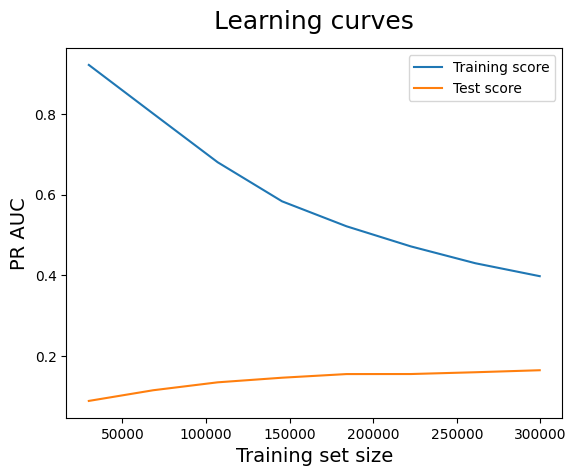

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    model_lgbm,
    X,
    y,
    cv=5,
    scoring="average_precision",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)


# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(val_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylabel('PR AUC', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.ylim(0,1)
plt.legend()

# Model_v2 - Grid Search for best hyperparameters

In [88]:
from sklearn.model_selection import RandomizedSearchCV


In [89]:
param_dist = {
    "n_estimators": np.arange(100, 600, 100),
    "learning_rate": np.linspace(0.01, 0.2, 20),
    "num_leaves": np.arange(20, 150, 10),
    "max_depth": [-1, 5, 10, 15]
}

search = RandomizedSearchCV(
    model_lgbm,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="average_precision",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print(search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'num_leaves': np.int64(40), 'n_estimators': np.int64(200), 'max_depth': 5, 'learning_rate': np.float64(0.04)}


# Model V2 with GridSearch best hyperparams (Best model to date)

In [90]:
model_lgbm_v2 = lgb.LGBMClassifier(
    objective="binary",
    scale_pos_weight=base_spw,
    random_state=42,
    verbosity=-1,
    n_jobs=-1,
    num_leaves=40,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.04
)

In [91]:
model_lgbm_v2.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,40
,max_depth,5
,learning_rate,0.04
,n_estimators,200
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [92]:
y_test_proba_2 = model_lgbm_v2.predict_proba(X_test)[:, 1]
y_test_pred_2  = (y_test_proba_2 >= 0.5).astype(int)

In [93]:
roc_auc_2 = roc_auc_score(y_test, y_test_proba_2)
pr_auc_2  = average_precision_score(y_test, y_test_proba_2)

In [94]:
roc_auc_2

0.7993137002096974

In [95]:
pr_auc_2

0.19894530247998707

In [96]:
recall_2 = recall_score(y_test, y_test_pred_2)
recall_2

0.6659563132658498

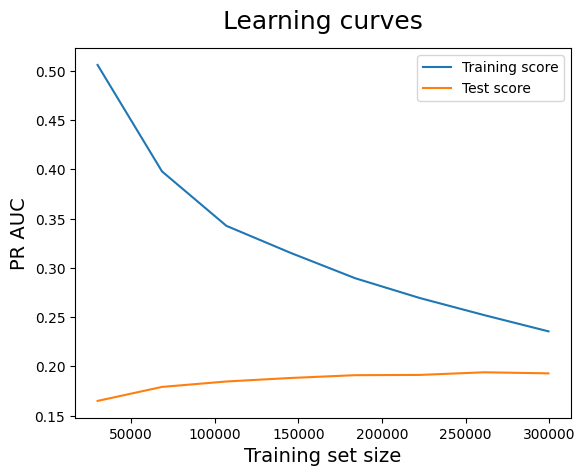

In [97]:
train_sizes, train_scores, val_scores = learning_curve(
    model_lgbm_v2,
    X,
    y,
    cv=5,
    scoring="average_precision",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)


# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(val_scores, axis=1)

plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylabel('PR AUC', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()